# Hands-on A.2 — Knowledge Base (Intermediate)
### NdabaX 2026 — Hands-on Workshop

Building a knowledge graph from a PubMedQA abstract: information extraction (OBIE vs OpenIE), ontology grounding with embeddings, and validation via back-translation.

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "datasets", "spacy", "openai", "python-dotenv", "pyvis", "networkx", "sentence-transformers", "matplotlib", "scipy"], check=True)
subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"], check=True)

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


CompletedProcess(args=['/Users/taineelliott/Documents/2026_NdabaX/collab notebook/.venv/bin/python', '-m', 'spacy', 'download', 'en_core_web_sm', '-q'], returncode=0)

In [ ]:
# @title Setup { display-mode: "form" }
import sys, os, pathlib

# Locate notebook_src/ whether it sits in the current folder (local, or after
# unzipping into /content) or one level down (e.g. after `git clone`).
_root = pathlib.Path.cwd()
if not (_root / "notebook_src").exists():
    for _p in sorted(_root.glob("*/notebook_src")):
        _root = _p.parent
        break
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# ── API key (one-time demo) ──────────────────────────────────────────────
# Paste your OpenAI key between the quotes for the demo, then DELETE it after.
# Leave blank to fall back to a local .env file.
OPENAI_API_KEY = ""
if OPENAI_API_KEY:
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

print("✅ notebook_src ready —", _root)

In [ ]:
# What this hands-on covers, end to end
from notebook_src.visuals import show
from notebook_src.display import render_a2_roadmap
show(render_a2_roadmap())

## Knowledge Base

<div style="
  background: linear-gradient(135deg, #7c3aed 0%, #a855f7 100%);
  border-radius: 12px; padding: 20px 28px; margin: 4px 0 12px 0;
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;
">
  <div style="color:rgba(255,255,255,0.7);font-size:11px;font-weight:600;
              letter-spacing:2px;text-transform:uppercase;margin-bottom:4px;">
    🧪 &nbsp;Hands-on A.2 · Intermediate
  </div>
  <div style="color:#fff;font-size:22px;font-weight:700;margin-bottom:4px;">
    Knowledge Base
  </div>
  <div style="color:rgba(255,255,255,0.85);font-size:13px;">
    Information extraction · Ontology · Open-domain · Knowledge representation · Graph design
  </div>
</div>

### Setup

<div style="margin-left:0px;border-left:4px solid #7c3aed;background:#f5f3ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;">
  <div style="font-size:16px;font-weight:700;color:#0f172a;">🔬 &nbsp;Setup</div>
  <div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Load a real PubMedQA abstract and inspect its structure before we extract knowledge from it.</div>
</div>

In [3]:
from datasets import load_dataset
from notebook_src.visuals import show
from notebook_src.display import render_abstract

ds  = load_dataset("qiaojin/PubMedQA", "pqa_labeled", split="train",
                   trust_remote_code=True)
ex  = ds[0]

# Metadata (title / authors fetched from NCBI for PMID 21645374)
TITLE   = "Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?"
AUTHORS = "Lord CEN, Wertman JN, Lane S, Gunawardena AHLAN"
JOURNAL = "BMC Plant Biology"
YEAR    = "2011"

# Expose raw fields for downstream cells
question = ex["question"]
contexts = ex["context"]["contexts"]
labels   = ex["context"]["labels"]

show(render_abstract(ex, TITLE, AUTHORS, JOURNAL, YEAR))
print(f"Loaded PMID {ex['pubid']} — {len(contexts)} section(s), "
      f"{sum(len(c) for c in contexts)} chars")


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'qiaojin/PubMedQA' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loaded PMID 21645374 — 2 section(s), 1692 chars


### Information Extraction

<div style="margin-left:0px;border-left:4px solid #7c3aed;background:#f5f3ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;">
  <div style="font-size:16px;font-weight:700;color:#0f172a;">🔬 &nbsp;Information Extraction</div>
  <div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Identifying and pulling structured facts — entities, relations and claims — from text</div>
</div>

In [4]:
from notebook_src.visuals import show
from notebook_src.display import render_ie_intro

show(render_ie_intro())

#### Ontology-based Information Extraction (OBIE)

<div style="margin-left:24px;border-left:3px solid #6d28d9;background:#f3f0ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;">
  <div style="font-size:14px;font-weight:700;color:#0f172a;">🗺️ &nbsp;Ontology-based Information Extraction (OBIE)</div>
  <div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Using a predefined ontology to guide extraction — high precision, closed schema</div>
</div>

In [5]:
from notebook_src.visuals import show
from notebook_src.display import render_obie_intro

show(render_obie_intro())

In [6]:
import os
from dotenv import load_dotenv
from notebook_src.visuals import show
from notebook_src.display import render_kg
from notebook_src.extraction import extract_obie

load_dotenv()
API_KEY = os.environ.get("OPENAI_API_KEY", "")

obie_triples = extract_obie(
    contexts=contexts,
    labels=labels,
    ontology_terms=ex["context"]["meshes"],
    api_key=API_KEY,
)

show(render_kg(obie_triples, strategy="OBIE"))
print(f"{len(obie_triples)} OBIE triples extracted")


18 OBIE triples extracted


#### Open-Domain Information Extraction (OpenIE)

<div style="margin-left:24px;border-left:3px solid #6d28d9;background:#f3f0ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;">
  <div style="font-size:14px;font-weight:700;color:#0f172a;">🌐 &nbsp;Open-Domain Information Extraction (OpenIE)</div>
  <div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Schema-free extraction across any domain — higher recall, noisier output</div>
</div>

In [7]:
from notebook_src.visuals import show
from notebook_src.display import render_openie_intro

show(render_openie_intro())

In [8]:
import os
from dotenv import load_dotenv
from notebook_src.visuals import show
from notebook_src.display import render_kg
from notebook_src.extraction import extract_openie

load_dotenv()
API_KEY = os.environ.get("OPENAI_API_KEY", "")

# Schema-free: the LLM returns EVERY relationship it sees in the text.
openie_triples = extract_openie(
    contexts=contexts,
    labels=labels,
    api_key=API_KEY,
)

# No ontology → colour nodes by abstract section instead of MeSH concept.
show(render_kg(openie_triples, strategy="OpenIE", color_by="section"))
print(f"{len(openie_triples)} OpenIE triples extracted")


52 OpenIE triples extracted


### Ontology

<div style="margin-left:0px;border-left:4px solid #7c3aed;background:#f5f3ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;">
  <div style="font-size:16px;font-weight:700;color:#0f172a;">📐 &nbsp;Ontology</div>
  <div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Defining the vocabulary of the KB: node types, edge types and their semantics</div>
</div>

In [9]:
from notebook_src.visuals import show
from notebook_src.display import render_ontology
from notebook_src.extraction import ONTOLOGY_TYPES

# The 5 MeSH descriptors for this abstract collapse into 4 UMLS semantic types.
show(render_ontology(ONTOLOGY_TYPES))


In [10]:
import os
from dotenv import load_dotenv
from notebook_src.visuals import show
from notebook_src.display import render_kg_pair, render_grounding
from notebook_src.extraction import ground_to_mesh, filter_by_types, ontology_type_names

load_dotenv()
API_KEY = os.environ.get("OPENAI_API_KEY", "")
meshes  = ex["context"]["meshes"]
allowed = ontology_type_names()

# 1) Ground every entity to the MeSH ontology with a biomedical embedding model
#    (BioLORD). cosine >= 0.8 => same concept => adopt that heading's ontological
#    type. OpenIE also keeps the LLM's inline type guess as a fallback.
obie_typed,   _           = ground_to_mesh(obie_triples,   meshes, threshold=0.8)
openie_typed, openie_rows = ground_to_mesh(openie_triples, meshes, threshold=0.8)

# 2) Show the embedding grounding for the schema-free OpenIE entities.
show(render_grounding(openie_rows, threshold=0.8))

# 3) Filter both graphs to the ontology's types, then compare side by side.
obie_f   = filter_by_types(obie_typed,   allowed)
openie_f = filter_by_types(openie_typed, allowed)
print(f"OBIE  : {len(obie_typed)} -> {len(obie_f)} triples")
print(f"OpenIE: {len(openie_typed)} -> {len(openie_f)} triples  (now the same ontological scope)")

show(render_kg_pair(
    obie_f, openie_f,
    left_title="OBIE", right_title="OpenIE (type-filtered)",
    color_by="type",
))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ENTITY,LLM GUESS,NEAREST MeSH,SIMILARITY,→ ONTOLOGY TYPE
leaves,Organism,Plant Leaves,0.89,Anatomical Structure
Programmed cell death,Biological Process,Apoptosis,0.83,Biological Process
the regulated death of cells within an organism,Biological Process,Apoptosis,0.75,Biological Process
death of cells,Biological Process,Apoptosis,0.74,Biological Process
mitochondrial dynamics,Cell Component,Mitochondria,0.74,Cell Component
these mitochondrial stages,Biological Process,Mitochondria,0.68,Biological Process
plant,Organism,Plant Leaves,0.66,Organism
The role of mitochondria during PCD,Cell Component,Mitochondria,0.66,Cell Component
lace plant leaves,Organism,Plant Leaves,0.64,Organism
cells,Cell Component,Cell Differentiation,0.64,Cell Component


OBIE  : 18 -> 8 triples
OpenIE: 52 -> 27 triples  (now the same ontological scope)


### Validation

<div style="margin-left:0px;border-left:4px solid #0d9488;background:#f0fdfa;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;">
  <div style="font-size:16px;font-weight:700;color:#0f172a;">✅ &nbsp;Validation</div>
  <div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Back-translate the triples into an abstract and measure how faithfully they preserved the meaning — calibrated against STS-B relatedness levels</div>
</div>

In [11]:
import os
from dotenv import load_dotenv
from notebook_src.visuals import show
from notebook_src.display import render_abstract_comparison
from notebook_src.validation import back_translate, text_cosine

load_dotenv()
API_KEY = os.environ.get("OPENAI_API_KEY", "")

# Round-trip test: reconstruct the abstract from the OPEN-DOMAIN triples only.
original_abstract = "\n\n".join(contexts)
reconstructed     = back_translate(openie_triples, API_KEY)

# Cosine similarity under the SAME model we calibrate against STS-B below.
sim = text_cosine(original_abstract, reconstructed)
print(f"Back-translation cosine similarity: {sim:.3f}")

show(render_abstract_comparison(original_abstract, reconstructed, sim))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Back-translation cosine similarity: 0.963


#### Calibrating cosine similarity with STS-B

<div style="margin-left:24px;border-left:3px solid #0d9488;background:#f0fdfa;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;">
  <div style="font-size:12px;color:#475569;line-height:1.5">A raw cosine number is hard to interpret. <b>STS-B</b> is a benchmark of sentence pairs each rated 0 (unrelated) &rarr; 5 (equivalent) by humans. Running our embedding model over it shows which cosine ranges correspond to which level of relatedness — so we can read our back-translation score against real human judgements.</div>
</div>

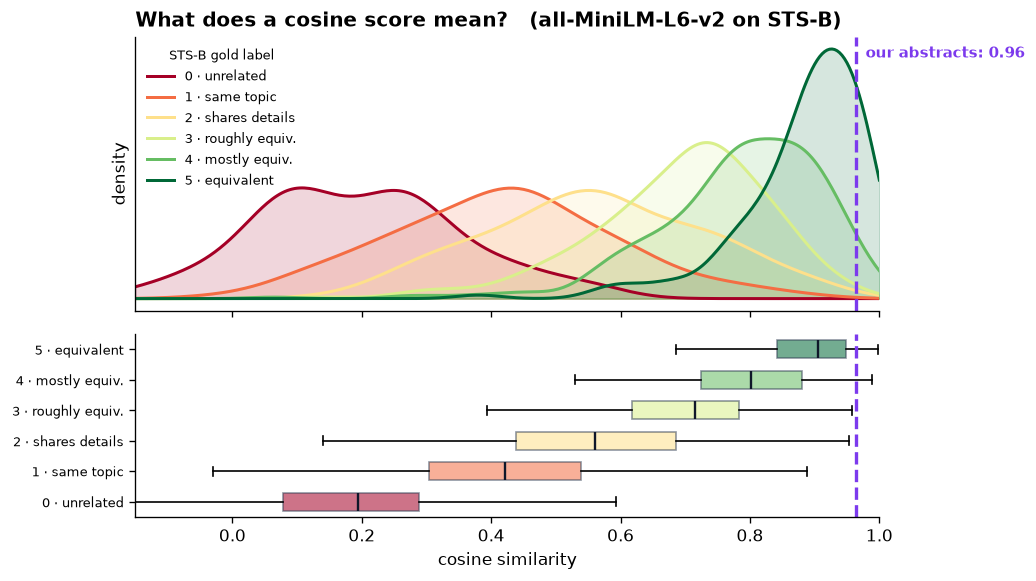

Our reconstruction (cos=0.96) sits nearest STS-B level 5 — 5 · equivalent.


In [12]:
from notebook_src.validation import stsb_cosine_by_category, plot_calibration

# Run the embedding model over STS-B and group cosine by human relatedness level.
cat_cos = stsb_cosine_by_category(split="test")

# Density per level + box-and-whiskers below; mark our back-translation similarity.
level = plot_calibration(cat_cos, highlight=sim, highlight_label="our abstracts")
if level:
    print(f"Our reconstruction (cos={sim:.2f}) sits nearest STS-B level {level[0]} — {level[1]}.")

### Knowledge Representation

<div style="margin-left:0px;border-left:4px solid #7c3aed;background:#f5f3ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;">
  <div style="font-size:16px;font-weight:700;color:#0f172a;">🧠 &nbsp;Knowledge Representation</div>
  <div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Choosing how to encode facts so they are queryable, traversable and maintainable</div>
</div>

In [13]:
from notebook_src.visuals import show
from notebook_src.display import render_kr_intro

# We have a bag of triples. A knowledge graph is a *property graph*: typed nodes
# and directed, labelled edges, each carrying properties. Four levers get us there.
show(render_kr_intro())

#### Entity Disambiguation

<div style="margin-left:24px;border-left:3px solid #6d28d9;background:#f3f0ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;">
  <div style="font-size:14px;font-weight:700;color:#0f172a;">🔗 &nbsp;Entity Disambiguation</div>
  <div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Merging the many surface forms of an entity into a single canonical node</div>
</div>

In [14]:
from notebook_src.graph import canonicalize_triples
from notebook_src.display import render_disambiguation

# OpenIE emits "mitochondria", "the mitochondria", "Mitochondria" as separate nodes.
# Merge them: cheap lexical normalisation, then BioLORD embedding similarity >= 0.9.
canon_triples, clusters, (n_before, n_after) = canonicalize_triples(openie_typed, threshold=0.9)

show(render_disambiguation(clusters, n_before, n_after, threshold=0.9))
print(f"{n_before} -> {n_after} unique entities  |  {len(canon_triples)} canonical triples")

CANONICAL NODE,MERGED SURFACE FORMS,
PCD,Programmed cell death,2 forms
Formation,formation,2 forms


66 -> 64 unique entities  |  51 canonical triples


#### Graph Design

<div style="margin-left:24px;border-left:3px solid #6d28d9;background:#f3f0ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;">
  <div style="font-size:14px;font-weight:700;color:#0f172a;">📊 &nbsp;Graph Design</div>
  <div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Structural decisions that determine how well the graph supports retrieval and reasoning</div>
</div>

In [15]:
from notebook_src.graph import build_graph
from notebook_src.extraction import filter_by_types, ontology_type_names
from notebook_src.display import render_graph_design

show(render_graph_design())

# Focus the graph on our ontology's types (drop off-schema OpenIE noise), then
# assemble the property graph: directed edges, symmetric-relation flags, temporal
# scopes and provenance are all attached here.
kg_triples = filter_by_types(canon_triples, ontology_type_names())
kg = build_graph(kg_triples)
print(f"Property graph: {kg.number_of_nodes()} nodes, {kg.number_of_edges()} edges "
      f"(disambiguated + ontology-typed)")

Property graph: 37 nodes, 26 edges (disambiguated + ontology-typed)


##### Properties, Directionality, Temporal & Metadata

<div style="margin-left:48px;border-left:3px solid #6d28d9;background:#f0ecff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;">
  <div style="font-size:14px;font-weight:700;color:#0f172a;">🔩 &nbsp;Properties, Directionality, Temporal & Metadata</div>
  <div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Properties: attributes on nodes/edges &middot; Directionality: what A&rarr;B means &middot; Temporal: validity windows &middot; Metadata: provenance, confidence, source</div>
</div>

In [16]:
from notebook_src.display import render_edge_anatomy

# Dissect one relationship to see every property it carries. Prefer an edge that
# has a temporal scope so all the facets show up at once.
_edges = list(kg.edges(data=True))
_s, _o, _d = next((e for e in _edges if e[2].get("temporal")), _edges[0])
show(render_edge_anatomy({"subject": _s, "object": _o, **_d}))

relationship type,spatial
confidence,100%
directionality,directed →
temporal scope,"window, stage, npcd"
source section,RESULTS
provenance mentions,1


#### The Consolidated Knowledge Graph

<div style="margin-left:24px;border-left:3px solid #6d28d9;background:#f3f0ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;">
  <div style="font-size:14px;font-weight:700;color:#0f172a;">📈 &nbsp;The Consolidated Knowledge Graph</div>
  <div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">The clean, typed, disambiguated graph — everything assembled into one queryable structure</div>
</div>

In [17]:
from notebook_src.display import render_kg, render_graph_stats
from notebook_src.graph import graph_stats

# The payoff: one coherent, disambiguated, typed graph — coloured by ontology type.
show(render_kg(kg_triples, strategy="Consolidated KG", color_by="type"))
show(render_graph_stats(graph_stats(kg)))

### Key Takeaways

<div style="margin-left:0px;border-left:4px solid #7c3aed;background:#f5f3ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;">
  <div style="font-size:16px;font-weight:700;color:#0f172a;">🎓 &nbsp;Key Takeaways</div>
  <div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">The full knowledge-graph generation pipeline, end to end</div>
</div>

In [20]:
from notebook_src.display import render_takeaways
show(render_takeaways())